# HW2 - hardware security

## explain the c code

```c
#include "hal.h"
#include "simpleserial.h"
#include <stdint.h>
#include <stdlib.h>


/*
v_func - 
    If the length of  the message does not match to 9 bytes (what it should be), it return to the user 1 byte with value of 0Xff.
    After that we do some calculation to update the value of sum and res , we close this calculation with trigger_high, trigger_low so the capture know      when to take the measurements.
    In the calculation it convert first from char to int(we send the data as chars so we convert it here) -
    uint8_t num = (msg[i] - '0');
    Do sum calculation that envolves each and each byte from the message.
    The function verify that you put a leagal ID

    *** we do changes to the function that it will be correct - where you have comment near (//<===).
*/

uint8_t v_func(uint8_t* msg, uint8_t len)
{
    uint8_t res = 255;
    if(len != 9) {
        simpleserial_put('r', 1, &res);
        return 0x00;
    }

    /* < traces start here > */
    trigger_high(); 
    ///// change here
    uint8_t sum = 0;
    for(int i=0; i<len; i++) {
        uint8_t num = (msg[i] - '0');
        num *= i % 2 + 1;  //<=== I added +1 here
        num = num % 10 + num / 10;  //<===
        sum += num;
    }
    res = sum % 10 == 0;  //<=== I switch to equal
    /////
	
    /* < traces end here > */
    trigger_low(); 

    
    res = res ? 'Y' : 'N';
    /* < send back result > */
    simpleserial_put('r', 1, &res); 
    return 0x00;
}


/*
f_func - 
    If the length of  the message does not match to 8 bytes (what it should be), it return to the user 1 byte with value of 0Xff.
    After that we do some calculation to update the value of res , we close this calculation with trigger_high, trigger_low so the capture know when to      take the measurements.
    In the calculation it convert first from char to int(we send the data as chars so we convert it here) -
    uint8_t num = (msg[i] - '0');
    Do sum calculation that envolves each and each byte from the message.
    Then it converts it back to char - res += '0';
    And sends this back.
    It calcs the last digit of ID.

*/
uint8_t f_func(uint8_t* msg, uint8_t len)
{
    uint8_t res = 255;
    if(len != 8) {
        simpleserial_put('r', 1, &res);
        return 0x00;
    }

    /* < traces start here > */
    trigger_high(); 
    ///// change here
    uint8_t sum = 0;
    for(int i=0; i<len; i++) {
        uint8_t num = (msg[i] - '0');
        num *= i % 2 + 1;
        num = num % 10 + num / 10;
        sum += num;
    }
    res = (200-sum) % 10;  //<===
    /////
    /* < traces end here > */
    trigger_low(); 

    
    res += '0';
    /* < send back result > */
    simpleserial_put('r', 1, &res);
    return 0x00;
}
/*
main-
    In the main we do hardware setup, we add 2 commands so the target will know how to handle the data we will send it.
    simpleserial_addcmd('a', 9, v_func); - add command with command char ‘a’, length of data is 9 an the function that will be preformed on the target       is v_func.
    simpleserial_addcmd('b', 8, f_func);- add command with command char ‘b’, length of data is 8 an the function that will be preformed on the target is     f_func.
    After we added this two commands to the target we will go into infinite loop that the target will read packets and handle them according the             commands that the target knows to handle.
*/

int main(void)
{
    platform_init();
    init_uart();
    trigger_setup();
	simpleserial_init();
    
    simpleserial_addcmd('a', 9, v_func);
    simpleserial_addcmd('b', 8, f_func);
    while(1)
        simpleserial_get();
}
```


## Imports and SetUp

In [61]:
import chipwhisperer as cw
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm.notebook import trange


scope = cw.scope()
target = cw.target(scope, cw.targets.SimpleSerial)
scope.default_setup()
# scope.adc.samples=1  # what is this?

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 5968667                   to 31932745                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 0                         to 29538459                 
scope.clock.adc_rate                     changed from 0.0                       to 29538459.0               
scope.clock.clkgen_

Add here your docs

# compilatiom

In [ ]:
%%bash
make PLATFORM=CWLITEARM SOURCE=chipwhisperer_hw2_dpa.c

Add here your docs

# program the flash of the processor

In [65]:
hex = "output-CWLITEARM.hex"
cw.program_target(scope, cw.programmers.STM32FProgrammer, hex)

Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 4959 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 4959 bytes


Add here your docs cells

In [62]:
def execute_trace(command : str, user_input : str):
    """
    Executes a trace using the given command and input string, with the provided scope and target objects.

    Parameters:
        command (str): The command to send to the target.
        user_input (str): The input data to send to the target.
        scope: The scope object for controlling the capture process.
        target: The target object for sending and receiving data.

    Returns:
        tuple: A tuple containing the capture trace and the response from the target.
    """
    try:
        # Flush target and arm the scope
        target.flush()
        scope.arm()

        # Convert input to bytearray
        input_data = bytearray(user_input, "utf-8")

        # Send command and data to target
        target.simpleserial_write(command, input_data)

        # Capture the trace
        ret = scope.capture()
        if ret:
            print("ERROR: Capture failed.")
            return None, None

        # Retrieve the trace and the target response
        trace = scope.get_last_trace()
        response = target.simpleserial_read('r', 1).decode('utf-8')

        return trace, response
    except Exception as e:
        print(f"An error occurred: {e}")
        return None, None

## Function Verification

In [73]:
# check f_func
id = '324231992'
command = 'b'
user_input = id[:8]
trace, response = execute_trace(command, user_input)
print(response)


8


In [9]:
# check ID(1:9) with v_func
command2 = 'a'
user_input2 = id
trace2, response2 = execute_trace(command2, user_input2)
print(response2)

Y


In [74]:
# check ID(1:8) + response with v_func
command3 = 'a'
user_input3 = id[:8] + response
trace3, response3 = execute_trace(command2, user_input3)
print(response3)

Y


# Trigger Count Analysis 

In [75]:
# Do the analysis on v_func (as yahav talled us)
num_of_samples_in_op = scope.adc.trig_count
print(f"Trigger count: {num_of_samples_in_op}")
margin = 150
scope.adc.samples = num_of_samples_in_op + margin
print(f"Total samples num included margins: {scope.adc.samples}")


Trigger count: 728
Total samples num included margins: 878


##  Noise Reduction and Visualization

### 1. Collect 100 traces for each partner’s ID

In [149]:
alons_id = '324231992'
eyals_id = '213099468'

id_list = [alons_id, eyals_id]
trace_dict = {id_val: [] for id_val in id_list}

for id_num in id_list:
    print(f"Capturing 100 traces for ID: {id_num}")
    for _ in range(100):
        trace, response = execute_trace('a', id_num)
        trace_dict[id_num].append((id_num, trace))

    


Capturing 100 traces for ID: 488567200
Capturing 100 traces for ID: 168465100


###  2. Compute the trace-wise average of these traces to obtain a noise-reduced trace.

In [150]:
average_traces = {}

for id_val, traces in trace_dict.items():
    trace_arrays = np.array([trace for (_, trace) in traces])
    avg_trace = np.mean(trace_arrays, axis=0)
    average_traces[id_val] = avg_trace

###  3. a.plot of the noise-reduced traces for both IDs

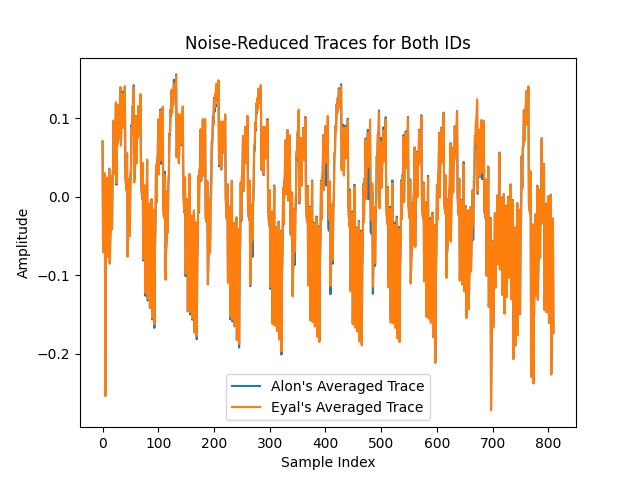

In [151]:
%matplotlib widget

avg_trace_alon = average_traces[alons_id] 
avg_trace_eyal = average_traces[eyals_id] 
plt.figure()
plt.plot(avg_trace_alon, label="Alon's Averaged Trace")
plt.plot(avg_trace_eyal, label="Eyal's Averaged Trace")
plt.title("Noise-Reduced Traces for Both IDs")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()

### 3.b plot of the differences between the traces

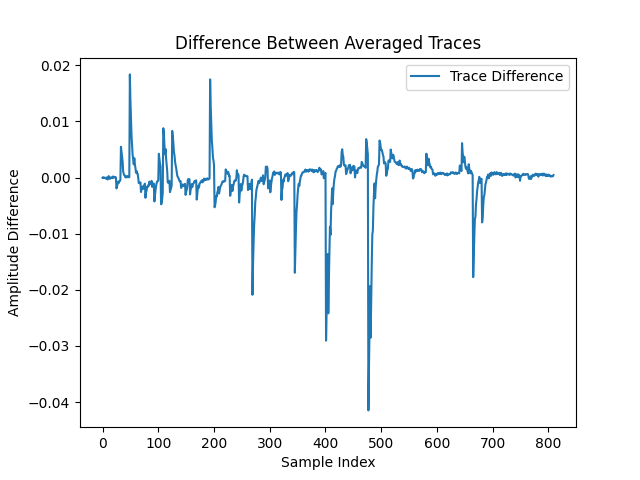

In [152]:
difference_trace = avg_trace_alon - avg_trace_eyal
plt.figure()
plt.plot(difference_trace, label="Trace Difference")
plt.title("Difference Between Averaged Traces")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude Difference")
plt.legend()

4. If there a big diffrence in the traces when the ID changes this bad for security because there is a leak of information that can be use by people that want to attack it....

## Differential Power Analysis (DPA) Attack

###  1. Generate a random 8-digit and use it as input to f_func to create random 9-digit ID .

In [54]:
random_8_digit = str(random.randint(10_000_000, 99_999_999))
_, response_to_random_8_digits = execute_trace('b', random_8_digit)
random_id = random_8_digit + response_to_random_8_digits
print(f"The random ID: {random_id}")

The random ID: 967746314


###  2. Collect leakage trace for this ID over v_func.


In [55]:
trace_to_random, _ = execute_trace('a', random_id)

### 3/4/5. Design and implement a DPA attack to recover the unknown ID.

##### functions for the DPA 

In [31]:
def find_last_zero_stable_index(diff, tol=0.05, max_glitches=10):
    """
    find the fisrt idx that dont inside the tolarance 
    """
    mask = diff > tol  
    
    glitch_indices = np.where(mask)[0]

    if len(glitch_indices) >= max_glitches:
        return glitch_indices[max_glitches - 1]
    else:
        return len(diff) 
    
def capture_average_trace(guess_id, num_traces=20):
    """
    Capture `num_traces` for a given guess_id and return the average trace.
    """
    traces = [execute_trace('a', guess_id)[0] for _ in range(num_traces)]
    return np.mean(traces, axis=0)

def score_guess(trace_target, avg_trace, tol, max_glitches):
    """
    Score a guess by finding the stable matching index in the trace difference.
    """
    diff = np.abs(trace_target - avg_trace)
    return  find_last_zero_stable_index(diff, tol, max_glitches)

def guess_digit(trace_target, recovered_prefix, digit_pos, id_length, tol, max_glitches, num_traces):
    """
    Guess a single digit at `digit_pos` by testing all values 0–9 and selecting the best match.
    """
    best_digit = None
    best_score = -1

    for candidate in range(10,100):
        guess_id = recovered_prefix + str(candidate) + "9" * (id_length - digit_pos - 2)
        avg_trace = capture_average_trace(guess_id, num_traces)
        score = score_guess(trace_target, avg_trace, tol, max_glitches)

        if score > best_score:
            best_score = score
            best_digit = str(candidate)

    return best_digit, best_score



def expand_candidates(initial_prefixes, id_length, trace_to_random, tol, max_glitches, num_traces, threshold=5):
    """
    Recover the possibility digits of the next id.
    """
    new_candidates = []
    scores = []
    mse_list = []
    traces_list = []
    
    for prefix in initial_prefixes:
        for d in range(10):
            candidate = prefix + str(d)
            guess_id_8_digits = candidate + "9" * (id_length - len(candidate) - 1)  # pad to length
            guess_id = guess_id_8_digits + execute_trace('b', guess_id_8_digits)[1]
            avg_trace = capture_average_trace(guess_id, num_traces)
            score = score_guess(trace_to_random, avg_trace, tol, max_glitches)
            if(len(candidate) == 8):
                mse = np.mean((avg_trace - trace_to_random) ** 2)
                trace_to_append = avg_trace
            else:
                mse = 0 
                trace_to_append = 0
                
            scores.append(score)
            new_candidates.append(candidate)
            mse_list.append(mse)
            traces_list.append(trace_to_append)

    
    scores = np.array(scores)
    unique_scores = np.unique(scores)
    if len(unique_scores) == 1:
        max_score = unique_scores[0]
    else:
        filtered = unique_scores[unique_scores < len(trace_to_random)]
        max_score = np.max(filtered)
        
    idx_close = np.where(max_score - scores < threshold)[0]
    return [new_candidates[i] for i in idx_close],[mse_list[i] for i in idx_close],[traces_list[i] for i in idx_close]



##### implimitation of the dpa attack

We will start with empty id.
Then we will try all the possibilities to the first digit 0-9 and find their score that calculted according the last idx of the diff trace that still inside the tolerance we choose(in every digit we will add only few combinations will continue).
we will do it untill we get to the 8 digit we will find all ID's that inside a tolance that we choose (harder tolerance than before).
After we will have all this ID's we will do MSE of thier diff to the random trace and took the one with the smallest mse.

In [ ]:
tolerances = [0.03, 0.03, 0.03, 0.03, 0.03, 0.03,0.03,0.0025] 
nums_traces = [3,3,3,3,3,3,3,25]

for level in range(8):  # 8 digits to guess 
    prefixes,mse_list,traces_list = expand_candidates(
        prefixes = [""],
        id_length=9,
        trace_to_random=trace_to_random,
        tol=0.03,
        max_glitches=1,
        num_traces=2,
        threshold=5
    )
    print(f"Level {level}: {len(prefixes)} prefixes, that are {prefixes}")

# Pair each prefix with its MSE
pairs = list(zip(mse_list, prefixes))

# Find the pair with the smallest MSE
min_mse, best_prefix = min(pairs)

print(f"Best prefix: {best_prefix} (MSE: {min_mse})")

the methood above can take large time but it accurate.

### DPA ATTACK 0.2

We will implement it in another way but less accurate.

## for eyal(to delete after)

what yahav did and told me to add is that he found where in the time trace the calc of sum = 0 happend, and after this the calculation for each digit. (each digit has separate time of calc).
for the times of each digit he took this samples calc abs(diff)/n_samples and took the smallest(you dont need to normelized).

i will add a code that i did in the start that suppose to found the samples that each digit is calculated (maybe you should take something narrower - i think it can maybe behave strange on the edges).

### finding the samples range for each loop iteration

we can see easelly that each iter depand only in the exact digit of the id, we will take this knowledge and for the beginning will find the sample range for each iter and after that we can attack this easelly using the response of the digits from 0 to 9 to the iteration and then only need a test to find the right digit in each range and then to recover our ID.

In [ ]:
digit_ranges = []  
threshold = 0.015  # adjust this based on your trace scale
cycles_list = []
cycles_list.append(0)

for i in range(10):
    id1 = list("999999999")
    id2 = list("111111111")
    for j in range(i):
        id1[j] = "0"
        id2[j] = "0"
    id1 = "".join(id1)
    id2 = "".join(id2)
    print(id1)
    print(id2)

    avg1 = np.mean([execute_trace('a', id1)[0] for _ in range(20)], axis=0)
    avg2 = np.mean([execute_trace('a', id2)[0] for _ in range(20)], axis=0)
    diff = avg1 - avg2

    start = cycles_list[-1] # the first idx will be ok (no glitching)
    # Take absolute value and find above-threshold region
    abs_diff = np.abs(diff)
    above = np.where((abs_diff > threshold)& (np.arange(len(abs_diff)) > start))[0]
    
    if len(above) == 0:
            # Plot with red region showing the POI
        plt.figure()
        plt.plot(diff)
        print(f"Skipping Digit {i} — no difference detected")
        continue

    first_idx_above = above[0]
    cycles_list.append(above[0])

    end = cycles_list[-1]
    cycles_list[-1] += 1 # for the next time will start from the last idx + 1  

    digit_ranges.append((start,end))

    # Plot with red region showing the POI
    plt.figure()
    plt.plot(diff)
    plt.axvspan(start, end, color='red', alpha=0.3, label=f"Digit {i} = [{start}, {end}]")
    plt.title(f"Difference Trace — Digit {i} changed")
    plt.xlabel("Sample Index")
    plt.ylabel("Power Difference")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


we can see from the graphsthat the first iter start in idx 38 and that every iteration is 63 samples.

In [ ]:
def mse(x, y):
    return np.mean((x - y) ** 2)

def recover_next_id_digit(initial_prefix, id_length, trace_to_random, num_traces,start_idx,stop_idx):
    """
    Recover the next digit of the id.
    """
    new_candidates = []
    scores = []
    mse_list = []
    traces_list = []
    
    for d in range(10):
        candidate = prefix + str(d)
        guess_id_8_digits = candidate + "9" * (id_length - len(candidate) - 1)  # pad to length
        guess_id = guess_id_8_digits + execute_trace('b', guess_id_8_digits)[1]
        avg_trace = capture_average_trace(guess_id, num_traces)
        avg_trace_relavant_idxs = avg_trace[start_idx:stop_idx]  
        trace_to_random_relavant_idxs = trace_to_random[start_idx:stop_idx]
        score = mse(avg_trace_relavant_idxs, trace_to_random_relavant_idxs)                
        scores.append(score)
        new_candidates.append(candidate)
    
    
    scores = np.array(scores)
    min_score_idx = np.argmin(scores)
    return new_candidates[min_score_idx]


def reconstruct_id_direct(random_trace):
    digit_range_start = 38
    digit_window = 63
    num_digits = 8
    num_traces = 25 # TO ADJUST
    prefix = ""
    for level in range(8):  # 8 digits to guess 
        start_idx = digit_range_start + i * (digit_window + 1)
        end_idx = start + digit_window
        prefix = recover_next_id_digit(prefix, id_length=9, trace_to_random, num_traces,start_idx,end_idx)
        print(f"The guess for {level+1} loop is: {prefix}")
        
    guess_id = prefix + execute_trace('b', prefix)[1]
    return guess_id



### now we will perform the attack

In [ ]:
guess_id = reconstruct_id_direct(random_trace)
print(f"Our guess ID is: {guess_id}")